In [104]:
print("test")

test


In [105]:
from datasets import load_dataset
import numpy as np


In [106]:
ds = load_dataset("imdb")

In [107]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [108]:
train_df = ds['train'].to_pandas()

In [109]:
train_df.sample(10)

,text,label
19095,"After viewing several episodes of this series,...",1
17342,"Rod Serling was, of course, a genius and his w...",1
12045,This apocalyptic zombie film tries to be vicio...,0
17522,"True, it does not follow the book very closely...",1
18891,If you like cars you will love this film!<br /...,1
12086,This was a disappointing film. The people seem...,0
21661,"Purple Rain... what else can i say, the title ...",1
7034,Once again the same familiar story about a man...,0
14787,Dan Katzir has produced a wonderful film that ...,1
7230,I kind of feel like a genius; I feel like I'm ...,0


In [110]:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [111]:
train_df['sentiment']= np.where(train_df.label==1,"positive","negative")

In [112]:
train_df

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative
3,This film was probably inspired by Godard's Ma...,0,negative
4,"Oh, brother...after hearing about this ridicul...",0,negative
...,...,...,...
24995,A hit at the time but now better categorised a...,1,positive
24996,I love this movie like no other. Another time ...,1,positive
24997,This film and it's sequel Barry Mckenzie holds...,1,positive
24998,'The Adventures Of Barry McKenzie' started lif...,1,positive


In [113]:
train_df.sentiment.value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

<Axes: >

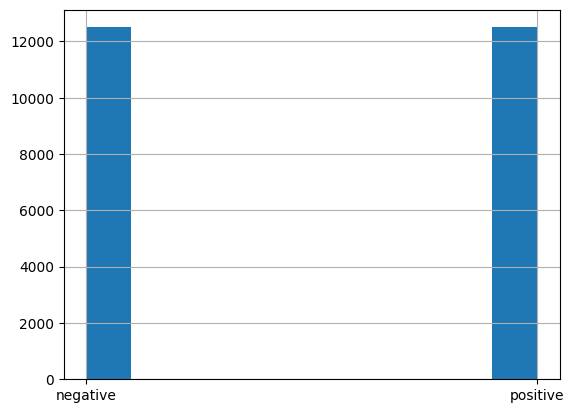

In [114]:
train_df.sentiment.hist()

In [115]:
from sklearn.model_selection import train_test_split

In [116]:
examples_df , gold_examples_df = train_test_split(train_df, test_size=0.2, random_state=123
)

In [117]:
examples_df.shape, gold_examples_df.shape

((20000, 3), (5000, 3))

In [118]:
columns = ['text', 'sentiment']
gold_examples = (gold_examples_df[columns]
                 .sample(10, random_state=34)
                 .to_json(orient='records'))

In [119]:
import json

In [120]:
json.loads(gold_examples)

[{'text': '"A Guy Thing" may not be a classic, but it sure is a good, funny comedy. The plot focuses on Paul (Jason Lee), who wakes up the morning after his bachelor party with no memory and Becky (Julia Stiles) lying naked in his bed. Before he can figure out what happened, he rushes Becky out of his apartment because his fiance Karen (Selma Blair) is coming. After that, as you could imagine, chaos ensues.<br /><br />Almost every single scene in "A Guy Thing" delivers loud laughs. The funniest moments come from when Paul imagines what could happen if he tells Karen. Selma Blair is a truly talented comedian, and the worst thing about this film is that she goes underused. Although, she turns out to be more funny than Stiles\' character, who actually isn\'t that interesting. Of course, not every comedy is perfect.<br /><br />As I said, "A Guy Thing" is no classic, but it\'s not bad either, 7/10.',
  'sentiment': 'positive'},
 {'text': "I've had to change my view on the worst film in the 

In [121]:
user_prompt_template = """'''{movie_review}'''"""

In [122]:
zero_shot_prompt_system = """
Classify the sentiment of the movie reviews presented in the input as positive or negative.

Movie reviews will be delimited by triple backticks ``` in the input.

Answer only as 'positive' or 'negative'.

Do not explain your answer.
"""

In [123]:
zero_shot_prompt = [
    {"role": "system", "content": zero_shot_prompt_system}
]

In [124]:
few_shot_prompt_system = """
Classify the sentiment of the movie reviews presented in the input as positive or negative.

Movie reviews will be delimited by triple backticks ``` in the input.

Answer only as 'positive' or 'negative'.

Do not explain your answer.
"""

In [125]:
examples_df.shape

(20000, 3)

In [126]:
positive_reviews_df = (examples_df[examples_df['sentiment']=='positive'][columns]
                     .sample(4)) 

In [127]:
negative_reviews_df = (examples_df[examples_df['sentiment']=='negative'][columns]
                       .sample(4))

In [128]:
positive_reviews_df 

,text,sentiment
15045,From the beginning of the show Carmen was ther...,positive
24827,Boasting an all-star cast so impressive that i...,positive
14044,Mendez and Marichal have provided us with a se...,positive
15059,"I remember Casper comic books, but don't remem...",positive


In [129]:
negative_reviews_df

,text,sentiment
2750,First off I'd like to point out that Sam Niel ...,negative
376,"After a day at work, I sat down to relax and t...",negative
6954,I watched this with a growing sense of unease....,negative
9824,It's rare that I feel a need to write a review...,negative


In [130]:
positive_reviews_df.shape, negative_reviews_df.shape

((4, 2), (4, 2))

In [131]:
positive_examples = (positive_reviews_df[columns]
                     .sample(4)
                     .to_json(orient='records'))

In [132]:
negative_examples = (negative_reviews_df[columns] # type: ignore
                     .sample(4)
                     .to_json(orient='records'))

In [133]:
json.loads(positive_examples)  

[{'text': 'Boasting an all-star cast so impressive that it almost seems like the "Mad Mad Mad Mad World" of horror pictures, "The Sentinel" (1977) is nevertheless an effectively creepy film centering on the relatively unknown actress Cristina Raines. In this one, she plays a fashion model, Alison Parker, who moves into a Brooklyn Heights brownstone that is (and I don\'t think I\'m giving away too much at this late date) very close to the gateway of Hell. And as a tenant in this building, she suffers far worse conditions than leaky plumbing and the occasional water bug, to put it mildly! Indeed, the scene in which Alison encounters her noisy upstairs neighbor is truly terrifying, and should certainly send the ice water coursing down the spines of most viewers. Despite many critics\' complaints regarding Raines\' acting ability, I thought she was just fine, more than ably holding her own in scenes with Ava Gardner, Burgess Meredith, Arthur Kennedy, Chris Sarandon and Eli Wallach. The pic

In [134]:
json.loads(negative_examples)

[{'text': "It's rare that I feel a need to write a review on this site, but this film is very deserving because of how poorly it was created, and how bias its product was.<br /><br />I felt a distinct attempt on the part of the film-makers to display the Palestinian family as boorish and untrustworthy. We hear them discuss the sadness that they feel from oppression, yet the film is shot and arranged in a way that we feel the politically oppressed population is the Jewish Israeli population. We see no evidence that parallels the position of the Palestinian teenager. We only hear from other Palestinians in prison. I understand restrictions are in place, but the political nature of the restrictions are designed to prevent peace.<br /><br />I came out of the film feeling that the mother of the victim was selfish in her mourning and completely closed minded due to her side of the fence, so to speak. She continued to be unwilling to see the hurt of the bomber's parents, and her angry and clo

In [135]:
import pandas as pd

In [136]:
ex=  pd.concat([positive_reviews_df, negative_reviews_df]) 

In [137]:
ex

,text,sentiment
15045,From the beginning of the show Carmen was ther...,positive
24827,Boasting an all-star cast so impressive that i...,positive
14044,Mendez and Marichal have provided us with a se...,positive
15059,"I remember Casper comic books, but don't remem...",positive
2750,First off I'd like to point out that Sam Niel ...,negative
376,"After a day at work, I sat down to relax and t...",negative
6954,I watched this with a growing sense of unease....,negative
9824,It's rare that I feel a need to write a review...,negative


In [138]:
examples = examples_df.sample(4*2, replace=False).to_json(orient='records')

In [139]:
json.loads(examples)

[{'text': 'I\'ve been trying to track down this film just by googling bad phrases about "teenagers seduce and kill man in his house" and such. I think I first saw parts of this film when I was about 10 years old when it was running on cable. It made quite an impression! It\'s the kind of film that kids know they shouldn\'t be watching, and switch the channel when their parents come in. When I saw who the cast was, I couldn\'t believe that some of these good actors were in such a horrible movie. Then again, if you like to see men who cheat on their wives get murdered, then this is an interesting film. Also, if I recall, there\'s some pretty interesting pseudo-lesbian moments. Probably the dumbest ending of all time, but still...memorable.',
  'label': 0,
  'sentiment': 'negative'},
 {'text': "Simply one of the best ever! Richard Brooks' adaptation of Truman Capote's non-fiction novel is truly an artistic achievement. Stunning black and white cinematography (that should have won an Oscar

In [140]:
def create_examples(dataset, n=4):

    columns = ['text', 'sentiment']

    positive_reviews_df = (
        dataset[dataset['sentiment'] == 'positive'][columns]
        .sample(n)
    )

    negative_reviews_df = (
        dataset[dataset['sentiment'] == 'negative'][columns]
        .sample(n)
    )

    examples_df = pd.concat([positive_reviews_df, negative_reviews_df])

    examples = examples_df.sample(n*2, replace=False)

    return examples.to_json(orient='records')

In [141]:
print(examples_df["sentiment"].value_counts())

sentiment
negative    10037
positive     9963
Name: count, dtype: int64


In [142]:
examples_df.shape

(20000, 3)

In [143]:
few_shot_prompt_system = create_examples(examples_df, n=2)

In [144]:
few_shot_examples = examples_df.to_json(orient='records')

In [145]:
json.loads(few_shot_examples)

[{'text': "Ulises is a literature teacher that arrives to a coastal town. There, he will fell in love to Martina, the most beautiful girl in town. They will start a torrid romance which will end in the tragic death of Ulises at the sea. Some years later, Martina has married to Sierra, the richest man in town and lives a quiet happy live surrounded by money. One day, the apparition of Ulises will make her passion to rise up and act without thinking the consequences. The plot is quite absurd and none of the actors plays a decent part. IN addition, three quarters of the film are sexual acts, which, still being well filmed, are quite tiring, as we want to see More development of the story. It is just a bad Bigas Luna's film, with lots of sex, no argument and stupid characters everywhere.",
  'label': 0,
  'sentiment': 'negative'},
 {'text': 'Tarzan the Ape Man is a remake of the 1932 film of the same time, and like that earlier film, it has little resemblance to Burroughs\' literary charac

In [146]:
def create_prompt(system_message, examples, user_prompt_template):

    prompt = [
        {"role": "system", "content": system_message},
       
    ]
    for example in json.loads(examples):
        review = example['text']
        sentiment = example['sentiment']
        prompt.append({"role": "user", "content": user_prompt_template.format(movie_review=review)})
        prompt.append({"role": "assistant", "content": f"{sentiment}"})
    return prompt

In [147]:
few_shot_prompt = create_prompt(
    few_shot_prompt_system,
    few_shot_examples,
    user_prompt_template
)

In [148]:
few_shot_prompt

[{'role': 'system',
  'content': '[{"text":"I\'ve noticed that a lot of people who post on the \\"Kerching!\\" board seem to hate this show, which I actually find very surprising. I think it\'s one of the best British kids\' shows there is. It\'s a shame it\'s ending because it\'s very funny (if a bit cheesy sometimes) and has great characters. The main character is a little like Del Boy, although quite a lot smarter. With his 2 best friends he tried to make a million pounds for his mum by starting an online business and adopting a pseudonym of \\"Rudeboy\\". His friends are Seymour (who likes to cook) and Danny (who is simple minded and the comic relief character). Throughout the show, some characters have left and new ones have come in, but it\'s always been entertaining and improving.","sentiment":"positive"},{"text":"This movie made me really mad because the main characters or all the characters have a southern accent. I\'ve lived in Iowa for 29 years and I know that people don\'t 

In [149]:
cot_few_sho_prompt_system = """
Classify the sentiment of the movie reviews presented in the input as positive or negative.

Movie reviews will be delimited by triple backticks ``` in the input.

Answer only as 'positive' or 'negative'.

Do not explain your answer.

Instructions:
1. Carefully read the text of the movie review and think through the option for sentiment provided.
2. Consider the overall sentiment of the review, and estimate the pribability of the review being positive
To reiterate the answer should strictly only contain the label : positive or negative
"""

In [150]:
cot_few_shot_prompt_system = create_prompt(
    cot_few_sho_prompt_system, 
    few_shot_examples, 
    user_prompt_template)

In [151]:
cot_few_shot_prompt_system

[{'role': 'system',
  'content': "\nClassify the sentiment of the movie reviews presented in the input as positive or negative.\n\nMovie reviews will be delimited by triple backticks ``` in the input.\n\nAnswer only as 'positive' or 'negative'.\n\nDo not explain your answer.\n\nInstructions:\n1. Carefully read the text of the movie review and think through the option for sentiment provided.\n2. Consider the overall sentiment of the review, and estimate the pribability of the review being positive\nTo reiterate the answer should strictly only contain the label : positive or negative\n"},
 {'role': 'user',
  'content': "'''Ulises is a literature teacher that arrives to a coastal town. There, he will fell in love to Martina, the most beautiful girl in town. They will start a torrid romance which will end in the tragic death of Ulises at the sea. Some years later, Martina has married to Sierra, the richest man in town and lives a quiet happy live surrounded by money. One day, the apparitio

In [152]:
from sklearn.metrics import f1_score

In [165]:
def evaluate_prompt(prompt, gold_examples, user_prompt_template, llm):

    predicted_sentiments = []
    ground_truth_sentiments = []
    for example in json.loads(gold_examples):
        review = example['text']
        sentiment = example['sentiment']
        user_input = {
            "role": "user",
            "content": user_prompt_template.format(movie_review=review)
        }

        try:
            resp = llm.invoke(prompt + user_input)
            text = resp.content.strip().lower()

            if 'negative' in text:
                predicted = 'negative'
            elif 'positive' in text:
                predicted = 'positive'
            else:
                predicted = 'unknown'
            predicted_sentiments.append(predicted)
            ground_truth_sentiments.append(sentiment)
            print(predicted, sentiment)
        except Exception as e:
            print(e)
            continue
        return f1_score(ground_truth_sentiments, predicted_sentiments, average='weighted')

In [154]:
from dotenv.ipython import load_dotenv

In [155]:
load_dotenv(override=True)

True

In [156]:
from langchain_openai import ChatOpenAI

In [157]:
llm1= ChatOpenAI(model="gbt-4o", temperature=0)

In [158]:
evaluate_prompt(zero_shot_prompt, gold_examples, user_prompt_template, llm1)

can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list


In [159]:
evaluate_prompt(zero_shot_prompt, gold_examples, user_prompt_template, llm1)

can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list


In [160]:
from langchain_ollama import ChatOllama

In [161]:
llm2 = ChatOllama(model="llma3.2", temperature=0)

In [166]:
evaluate_prompt(zero_shot_prompt, gold_examples, user_prompt_template, llm2) 

can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list
can only concatenate list (not "dict") to list


In [ ]:
()